In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

In [63]:
df = pd.read_csv('Divar.csv', low_memory=False)

In [64]:
lux_features = [
    "has_pool",
    "has_barbecue",
    "has_sauna",
    "has_jacuzzi"
]

non_lux_features = [
    "has_balcony",
    "has_elevator",
    "has_warehouse",
    "has_parking"
]

price_col = "price_value"
needed_cols = [price_col] + lux_features + non_lux_features

In [65]:
df_selected = df[needed_cols].copy()
df_selected.shape

(1000000, 9)

In [66]:
for col in lux_features + non_lux_features:
    print("\n", col)
    print(df_selected[col].value_counts(dropna=False).head(10))


 has_pool
has_pool
NaN      970610
False     25669
True       3721
Name: count, dtype: int64

 has_barbecue
has_barbecue
NaN      968802
False     23377
True       7821
Name: count, dtype: int64

 has_sauna
has_sauna
NaN      971521
False     27084
True       1395
Name: count, dtype: int64

 has_jacuzzi
has_jacuzzi
NaN      971272
False     26455
True       2273
Name: count, dtype: int64

 has_balcony
has_balcony
NaN         493589
true        392096
false        88855
True         20692
False         4545
unselect       223
Name: count, dtype: int64

 has_elevator
has_elevator
NaN      458251
True     365148
False    176601
Name: count, dtype: int64

 has_warehouse
has_warehouse
True     582313
NaN      271845
False    145842
Name: count, dtype: int64

 has_parking
has_parking
True     552542
NaN      271844
False    175614
Name: count, dtype: int64


In [67]:
bool_map = {
    True: 1,
    False: 0,
    "True": 1,
    "False": 0,
    "true": 1,
    "false": 0,
    "TRUE": 1,
    "FALSE": 0,
    1: 1,
    0: 0,
    "1": 1,
    "0": 0
}

for col in lux_features + non_lux_features:
    df_selected[col] = df_selected[col].map(bool_map)

In [68]:
df_selected[price_col] = pd.to_numeric(df_selected[price_col], errors="coerce")

In [69]:
price_check = df_selected[price_col].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
)
price_check

count    5.683460e+05
mean     1.736537e+10
std      5.878739e+11
min      0.000000e+00
1%       3.400000e+03
5%       2.600000e+08
25%      1.400000e+09
50%      2.840000e+09
75%      5.900000e+09
95%      2.100000e+10
99%      8.500000e+10
max      1.000000e+14
Name: price_value, dtype: float64

In [70]:
def has_any_feature(row):
    valid = row.dropna()
    
    if len(valid) == 0:
        return np.nan
    
    return int((valid == 1).any())

In [71]:
df_selected["has_lux"] = df_selected[lux_features].apply(has_any_feature, axis=1)
df_selected["has_non_lux"] = df_selected[non_lux_features].apply(has_any_feature, axis=1)

In [72]:
df_selected.head()

,price_value,has_pool,has_barbecue,has_sauna,has_jacuzzi,has_balcony,has_elevator,has_warehouse,has_parking,has_lux,has_non_lux
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,8.500000e+09,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,NaN,1.0
2,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,NaN,1.0
3,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,1.0,NaN,1.0
4,5.750000e+09,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,NaN,1.0


In [73]:
print("Luxury groups:")
print(df_selected["has_lux"].value_counts(dropna=False))

print("\nNon-luxury groups:")
print(df_selected["has_non_lux"].value_counts(dropna=False))

Luxury groups:
has_lux
NaN    968499
0.0     22855
1.0      8646
Name: count, dtype: int64

Non-luxury groups:
has_non_lux
1.0    688136
NaN    271844
0.0     40020
Name: count, dtype: int64


In [74]:
df_selected = df_selected.dropna(subset=[price_col]).copy()
df_selected = df_selected[df_selected[price_col] > 0]

In [75]:
df_selected[price_col].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
)

count    5.664440e+05
mean     1.742368e+10
std      5.888592e+11
min      1.000000e+00
1%       1.111110e+05
5%       3.000000e+08
25%      1.410000e+09
50%      2.850000e+09
75%      5.923500e+09
95%      2.100000e+10
99%      8.515700e+10
max      1.000000e+14
Name: price_value, dtype: float64

In [76]:
print("Luxury groups with valid price:")
print(df_selected["has_lux"].value_counts(dropna=False))

print("\nNon-luxury groups with valid price:")
print(df_selected["has_non_lux"].value_counts(dropna=False))

Luxury groups with valid price:
has_lux
NaN    544526
0.0     15665
1.0      6253
Name: count, dtype: int64

Non-luxury groups with valid price:
has_non_lux
1.0    414001
NaN    138576
0.0     13867
Name: count, dtype: int64


In [77]:
def group_summary(data, group_col, price_col):
    temp = data[[group_col, price_col]].dropna()

    return temp.groupby(group_col)[price_col].agg(
        count="count",
        mean="mean",
        median="median",
        std="std",
        min="min",
        q01=lambda x: x.quantile(0.01),
        q05=lambda x: x.quantile(0.05),
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        q95=lambda x: x.quantile(0.95),
        q99=lambda x: x.quantile(0.99),
        max="max",
        skew="skew"
    )

In [78]:
lux_summary = group_summary(df_selected, "has_lux", price_col)
non_lux_summary = group_summary(df_selected, "has_non_lux", price_col)

In [79]:
lux_summary

,count,mean,median,std,min,q01,q05,q25,q75,q95,q99,max,skew
has_lux,,,,,,,,,,,,,
0.0,15665,1.543494e+10,2.700000e+09,8.171339e+11,1.0,1111.0,3.040000e+08,1.500000e+09,5.000000e+09,1.500000e+10,5.372000e+10,1.000000e+14,117.491810
1.0,6253,1.168298e+10,3.000000e+09,2.911757e+11,1.0,111111.0,7.000000e+08,1.800000e+09,5.800000e+09,1.800000e+10,5.548000e+10,2.000000e+13,60.669096


In [80]:
non_lux_summary

,count,mean,median,std,min,q01,q05,q25,q75,q95,q99,max,skew
has_non_lux,,,,,,,,,,,,,
0.0,13867,8.632560e+09,1.380000e+09,2.232412e+11,1.0,550.0,11111111.0,8.500000e+08,2.380000e+09,6.500000e+09,1.986800e+10,1.111111e+13,43.289811
1.0,414001,1.586516e+10,3.250000e+09,5.341319e+11,1.0,111111.0,710000000.0,1.800000e+09,6.300000e+09,2.000000e+10,6.000000e+10,1.000000e+14,122.507704


In [81]:
def plot_group_price_distribution(data, group_col, price_col, title):
    temp = data[[group_col, price_col]].dropna().copy()

    q99 = temp[price_col].quantile(0.99)
    temp_plot = temp[temp[price_col] <= q99]

    group_0 = temp_plot.loc[temp_plot[group_col] == 0, price_col]
    group_1 = temp_plot.loc[temp_plot[group_col] == 1, price_col]

    plt.figure(figsize=(8, 4))
    plt.boxplot(
        [group_0, group_1],
        labels=["No", "Yes"],
        showfliers=False
    )
    plt.xlabel(group_col)
    plt.ylabel(price_col)
    plt.title(title + " - Boxplot up to 99th percentile")
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.hist(group_0, bins=60, alpha=0.6, label="No", density=True)
    plt.hist(group_1, bins=60, alpha=0.6, label="Yes", density=True)
    plt.xlabel(price_col)
    plt.ylabel("Density")
    plt.title(title + " - Histogram up to 99th percentile")
    plt.legend()
    plt.show()

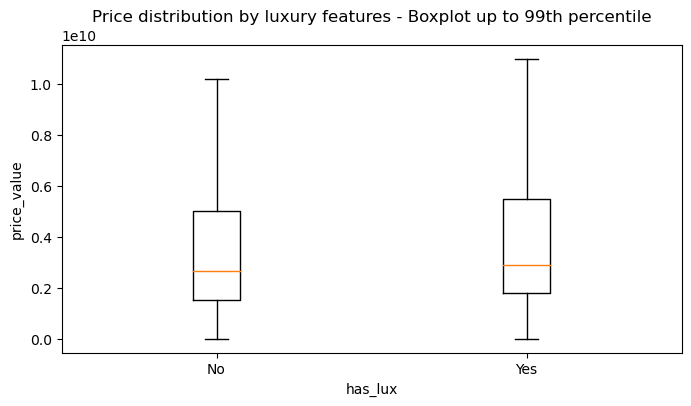

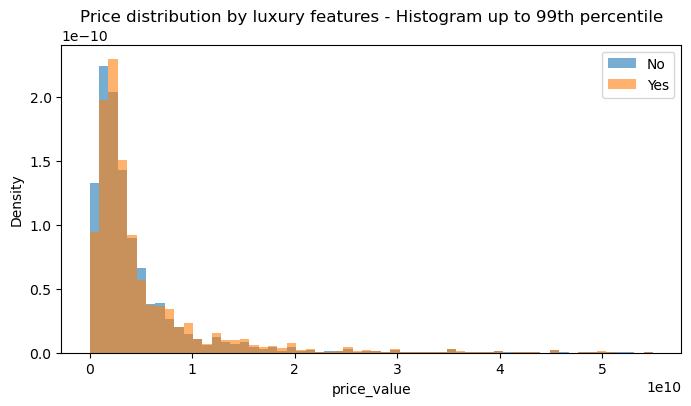

In [82]:
plot_group_price_distribution(
    df_selected,
    "has_lux",
    price_col,
    "Price distribution by luxury features"
)

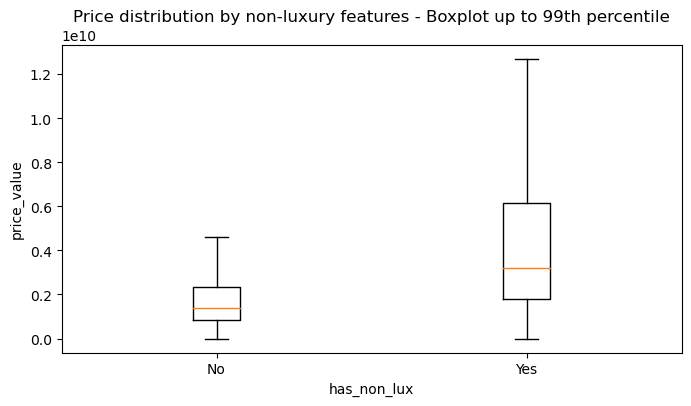

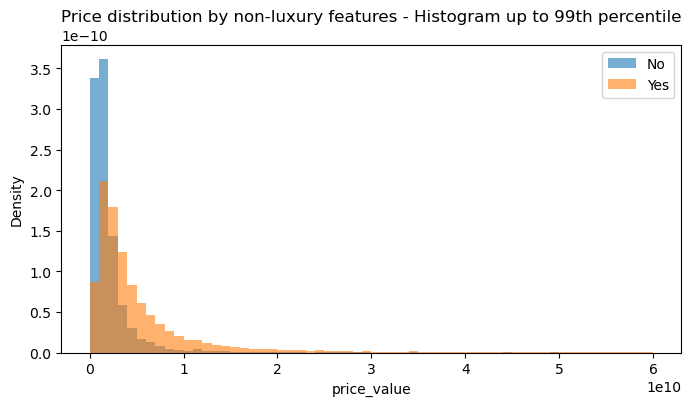

In [83]:
plot_group_price_distribution(
    df_selected,
    "has_non_lux",
    price_col,
    "Price distribution by non-luxury features"
)

In [84]:
df_test = df_selected.copy()

q01 = df_test[price_col].quantile(0.01)
q99 = df_test[price_col].quantile(0.99)

df_test = df_test[
    (df_test[price_col] >= q01) &
    (df_test[price_col] <= q99)
].copy()

In [85]:
q01, q99, df_test.shape

(111111.0, 85156999999.99487, (555618, 11))

In [86]:
lux_summary = group_summary(df_test, "has_lux", price_col)
non_lux_summary = group_summary(df_test, "has_non_lux", price_col)

In [87]:
lux_summary

,count,mean,median,std,min,q01,q05,q25,q75,q95,q99,max,skew
has_lux,,,,,,,,,,,,,
0.0,15274,4.676772e+09,2.710004e+09,6.777898e+09,111111.0,1111111.0,650000000.0,1.600000e+09,5.000000e+09,1.500000e+10,3.500000e+10,8.500000e+10,5.217808
1.0,6171,5.218465e+09,3.000000e+09,7.281241e+09,111111.0,107777777.4,780000000.0,1.800000e+09,5.650000e+09,1.700000e+10,3.630000e+10,8.500000e+10,4.673069


In [88]:
non_lux_summary

,count,mean,median,std,min,q01,q05,q25,q75,q95,q99,max,skew
has_non_lux,,,,,,,,,,,,,
0.0,13468,2.218050e+09,1.400000e+09,3.568522e+09,111111.0,1000000.0,246750000.0,9.000000e+08,2.400000e+09,6.400000e+09,1.500000e+10,8.000000e+10,9.623697
1.0,407167,5.691533e+09,3.250000e+09,7.841777e+09,111111.0,4200000.0,800000000.0,1.830000e+09,6.277500e+09,1.850000e+10,4.250000e+10,8.500000e+10,4.376705


In [89]:
def welch_test(data, group_col, price_col):
    temp = data[[group_col, price_col]].dropna()
    
    group_no = temp.loc[temp[group_col] == 0, price_col]
    group_yes = temp.loc[temp[group_col] == 1, price_col]
    
    test = stats.ttest_ind(
        group_yes,
        group_no,
        equal_var=False
    )
    
    mean_no = group_no.mean()
    mean_yes = group_yes.mean()
    mean_diff = mean_yes - mean_no
    pct_diff = (mean_diff / mean_no) * 100
    
    return {
        "group": group_col,
        "n_no": len(group_no),
        "n_yes": len(group_yes),
        "mean_no": mean_no,
        "mean_yes": mean_yes,
        "mean_diff": mean_diff,
        "pct_diff": pct_diff,
        "t_stat": test.statistic,
        "p_value": test.pvalue
    }

In [90]:
test_results = pd.DataFrame([
    welch_test(df_test, "has_lux", price_col),
    welch_test(df_test, "has_non_lux", price_col)
])

test_results

,group,n_no,n_yes,mean_no,mean_yes,mean_diff,pct_diff,t_stat,p_value
0,has_lux,15274,6171,4.676772e+09,5.218465e+09,5.416927e+08,11.582620,5.029719,4.991564e-07
1,has_non_lux,13468,407167,2.218050e+09,5.691533e+09,3.473483e+09,156.600802,104.893892,0.000000e+00
